<a href="https://colab.research.google.com/github/matthunter10/IT480-FA26/blob/main/Lab2_CNN_PetFinder_Starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2: CNN for Image Classification (PetFinder)

**Name:** *Darren Sluss & Matt Hunter*

This notebook has no starter code. Each section below tells you what to build and what questions to answer in your own words, but the code itself is yours to write. Use the CNN Fundamentals lecture and Lab 1 as your reference for syntax, not as something to copy from.

**Submission:** GitHub repo URL + this notebook's URL on Canvas.

## Setup

Clone the course repo (or your fork) to access the dataset, then import the libraries you expect to need. You will likely want `pandas`, `numpy`, `os`, image-loading tools (for example `PIL.Image`), `matplotlib`, `tensorflow`, and evaluation tools from `sklearn`. Add imports as you go, you don't need to guess all of them up front.

In [ ]:
# Clone the repo to access the data (only needs to run once per Colab session)
# !git clone <your-fork-url>


In [1]:
# Your imports here
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.utils import to_categorical

---
## Part A: Load and Prepare the Data

**What to do:**
1. Load `train.csv` and inspect it. You need the `PetID` and `Type` columns (`Type`: 1 = Dog, 2 = Cat).
2. Write code that loads each pet's primary photo from `train_images/`, resizes it to a consistent size of your choosing, and normalizes pixel values.
3. Build your `X` (images) and `y` (Dog/Cat) arrays.
4. Split into train and test sets. Decide, and justify, whether you need to stratify this split.
5. Report how many images you ended up with, and whether Dog and Cat are reasonably balanced.

**Note:** not every `PetID` in `train.csv` will have a matching photo file. Your loading code should skip missing images gracefully rather than erroring out.

**Answer in this notebook:**
- What image size did you choose, and why?
- Did you stratify your train/test split? Why or why not?


In [2]:
# Load train.csv here

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


*Your written answers for Part A:*

- Image size chosen and why: **N/A | Told not to answer and start with part B**
- Stratification decision and why: **N/A | Told not to answer and start with part B**


---
## Part B: Build a CNN From Scratch

**What to decide, and be ready to justify:**
- How many Conv2D and MaxPooling2D layers will you use?
- How many filters at each layer, and how does that number change as you go deeper?
- What kernel size will you use, and why?
- What does your Dense classifier head look like after the Flatten layer?
- What output layer and activation fits a Dog vs. Cat task specifically? Is this the same as Lab 1's binary classification setup, or different?

Write your architecture below, then write one paragraph justifying every choice, using the conventions from lecture (filters growing with depth, 3x3 kernels, funnel-shaped Dense layers, and so on).

In [ ]:
# Build your CNN model here

model = Sequential()

model.add(Conv2D(32, kernel_size= 3, activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D(pool_size= 2, strides = 2))

model.add(Conv2D(64, kernel_size= 3, activation='relu'))
model.add(MaxPooling2D(pool_size= 2, strides = 2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compile your model here

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

*Your architecture justification (one paragraph):*

For our CNN model, we used two Conv2D/MaxPooling2D blocks with 3 by 3 Kernel sizes becuase it is a good fit for capturing local patterns. We also used a 2 by 2 pooling size because of the 28x28 images to not shrink the images too much. The number of filters in the first layer is 32 followed by 64 in the second layer. This is standard practice to add more filters as we get to deeper layers. Early layers are looking for edges while the deeper layers are making shapes which is why we add more filters on the deeper layers. After we flatten, we use dense 128 layer to narrow features down before the output layer. Dense 10 is the output layer and we use softmax for each of the 10 classes to get a probability that adds up to 1.





---
## Part C: Train and Diagnose

**What to do:**
1. Train your model, saving the history.
2. Plot training vs. validation loss and accuracy.
3. Diagnose the fit: good fit, overfitting, or underfitting? Point to specific evidence from your own curve.
4. Evaluate on the test set and report accuracy.

In [ ]:
# Train your model here (save the result as `history`)

history = model.fit(
    x_train, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=64
)

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 46s 59ms/step - accuracy: 0.8078 - loss: 0.5268 - val_accuracy: 0.8695 - val_loss: 0.3708
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 44s 59ms/step - accuracy: 0.8753 - loss: 0.3458 - val_accuracy: 0.8813 - val_loss: 0.3372
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 45s 60ms/step - accuracy: 0.8928 - loss: 0.2956 - val_accuracy: 0.8876 - val_loss: 0.3112
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 45s 60ms/step - accuracy: 0.9029 - loss: 0.2662 - val_accuracy: 0.8904 - val_loss: 0.3149
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 43s 58ms/step - accuracy: 0.9126 - loss: 0.2388 - val_accuracy: 0.8946 - val_loss: 0.2935
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 44s 58ms/step - accuracy: 0.9195 - loss: 0.2186 - val_accuracy: 0.9064 - val_loss: 0.2522
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 81s 57ms/step - accuracy: 0.9268 - loss: 0.1982 - val_accuracy: 0.9100 - val_loss: 0.2557
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 43s 58ms/step - accuracy: 0.9329 - loss: 0.1834 - 

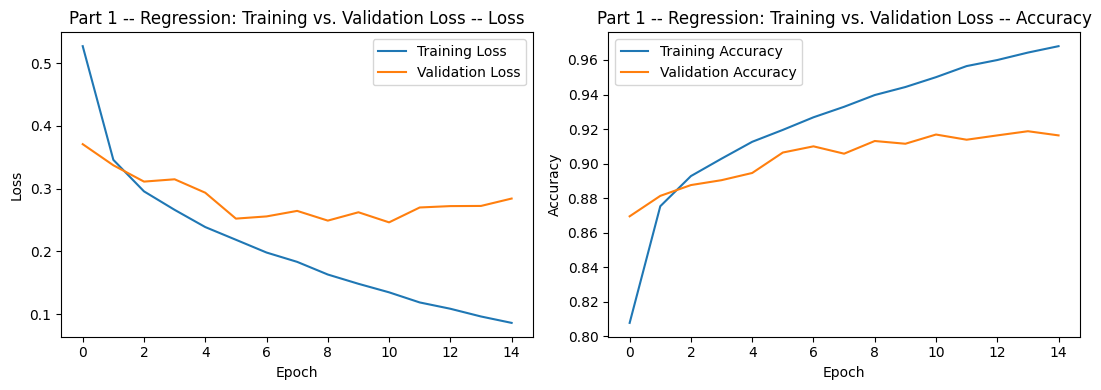

In [ ]:
# Plot training vs. validation loss and accuracy here
import matplotlib.pyplot as plt
def plot_history(history, title, show_accuracy=True):
    if show_accuracy:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        axes[0].plot(history.history["loss"], label="Training Loss")
        axes[0].plot(history.history["val_loss"], label="Validation Loss")
        axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()
        axes[0].set_title(title + " -- Loss")

        axes[1].plot(history.history["accuracy"], label="Training Accuracy")
        axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
        axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()
        axes[1].set_title(title + " -- Accuracy")
        plt.tight_layout()
        plt.show()

plot_history(history, "Part 1 -- Regression: Training vs. Validation Loss")



*Your fit diagnosis, with specific evidence from your curve:*

The baseline model exhibits overfitting. While training loss continuously drops to  about 0.08 and training accuracy reaches about 96% over 15 epochs, validation loss bottoms out around epoch 6 before steadily creeping back up to about 0.28 while validation accuracy plateaus near 91%. This growing difference shows that after epoch 6, the model begins memorizing training data details rather than generalizing to unseen samples.


In [ ]:
# Evaluate on the test set and report accuracy here

test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9062 - loss: 0.3050
Test accuracy: 90.62%
Test Loss: 0.3050


---
## Part D: Improve the Model

Choose **one** path, based on what Part C showed you.

**If your baseline overfit:** apply Dropout, Early Stopping, or both, the same tools from Assignment 1, to your own CNN.

**If your baseline did not overfit, or you want to push accuracy further:** use Keras Tuner to search over at least 2 hyperparameters of your choosing. Keep the same test-set discipline from Assignment 1: tuning only touches training and validation data, the test set is touched once, at the end.

State which path you chose and why, before you start building it.

*Which path are you taking, and why:*

Since our original model showed signs of overfitting, we chose the path of adding Dropout and Early Stopping. By incorporating Dropout layers, we were able to prevent the network from relying too heavily on specific weights.Also with Early Stopping, it monitored the validation loss, this ensures training halts at optimal performance before the model begins memorizing data in the training set.


In [4]:
# Build your improved model here

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

improved_model = Sequential([
    Input(shape=(28, 28, 1)),

    Conv2D(32, 3, padding='same', activation='relu'),
    Conv2D(32, 3, padding='same', activation='relu'),
    MaxPooling2D(2),
    Dropout(0.25),

    Conv2D(64, 3, padding='same', activation='relu'),
    Conv2D(64, 3, padding='same', activation='relu'),
    MaxPooling2D(2),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

improved_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

improved_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 467,818 (1.78 MB)

 Trainable params: 467,818 (1.78 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
import matplotlib.pyplot as plt
def plot_history(history, title, show_accuracy=True):
    if show_accuracy:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        axes[0].plot(history.history["loss"], label="Training Loss")
        axes[0].plot(history.history["val_loss"], label="Validation Loss")
        axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()
        axes[0].set_title(title + " -- Loss")

        axes[1].plot(history.history["accuracy"], label="Training Accuracy")
        axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
        axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()
        axes[1].set_title(title + " -- Accuracy")
        plt.tight_layout()
        plt.show()

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 216s 284ms/step - accuracy: 0.7895 - loss: 0.5826 - val_accuracy: 0.8760 - val_loss: 0.3376
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 261s 282ms/step - accuracy: 0.8691 - loss: 0.3627 - val_accuracy: 0.9003 - val_loss: 0.2682
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 211s 282ms/step - accuracy: 0.8891 - loss: 0.3080 - val_accuracy: 0.9084 - val_loss: 0.2493
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 263s 283ms/step - accuracy: 0.8996 - loss: 0.2760 - val_accuracy: 0.9167 - val_loss: 0.2233
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 211s 282ms/step - accuracy: 0.9078 - loss: 0.2565 - val_accuracy: 0.9187 - val_loss: 0.2190
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 262s 281ms/step - accuracy: 0.9142 - loss: 0.2378 - val_accuracy: 0.9241 - val_loss: 0.2063
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 211s 281ms/step - accuracy: 0.9188 - loss: 0.2233 - val_accuracy: 0.9244 - val_loss: 0.2091
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 262s 282ms/step - accuracy: 0.9220 -

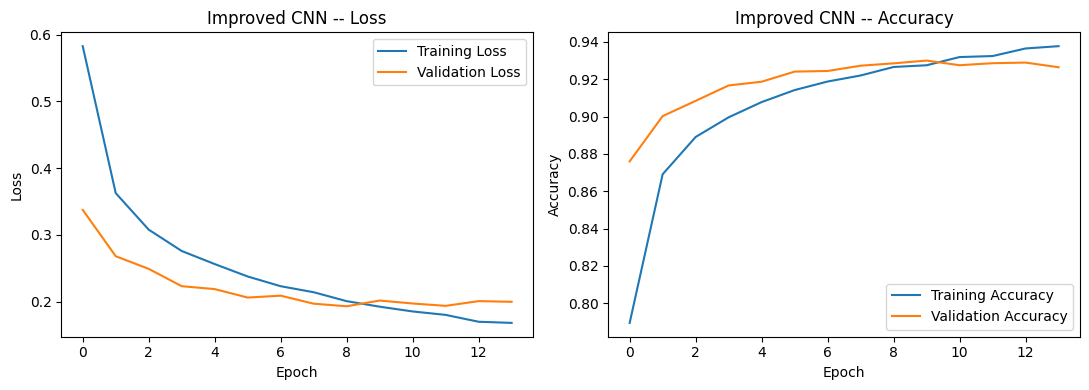

In [6]:
# Train your improved model here

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history_improved = improved_model.fit(
    x_train, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=64,
    callbacks=[early_stop]
)

plot_history(history_improved, "Improved CNN")


---
## Part E: Compare and Evaluate

Fill in your own results:

| | Baseline CNN | Improved CNN |
|---|---|---|
| Test accuracy | 90.62% | 92.79% |
| Fit pattern (good/over/under) | Overitting | Good Fit |
| What changed | Was the baseline model, no regularization  | Added Dropout layers and Early Stopping |

Report a confusion matrix for your improved model. Are Dogs or Cats more often misclassified? Do you have a guess as to why, based on looking at a few misclassified photos directly?

I think that cats were misclassified more often than dogs because the cat images in the dataset have a lot of other things in the background and they are taken from a closer range which could mess with distinguishing physical features.

Improved Model Test Accuracy: 92.79%
Improved Model Test Loss: 0.2087
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step


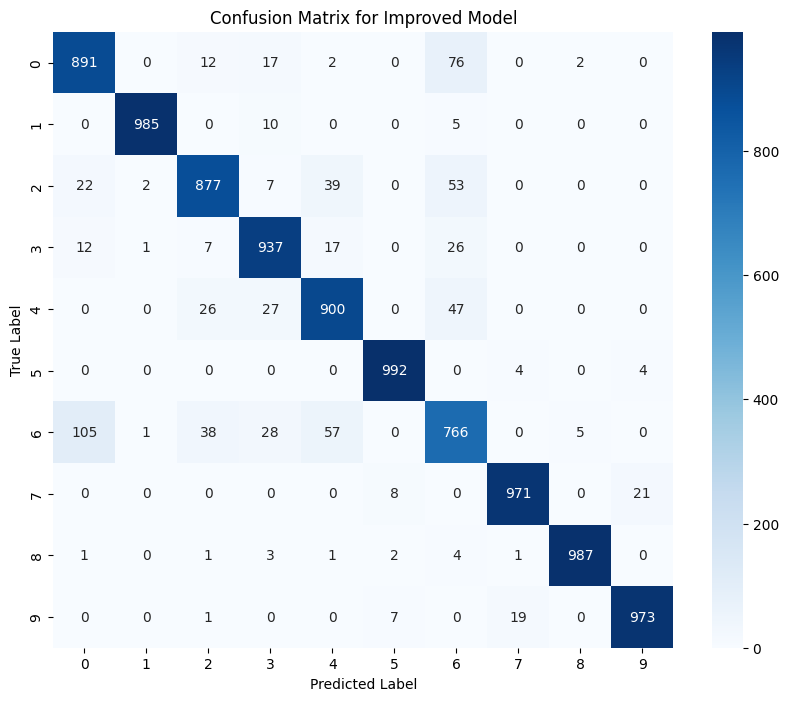

In [7]:
# Evaluate your improved model and build a confusion matrix here

test_loss_improved, test_accuracy_improved = improved_model.evaluate(x_test, y_test, verbose=0)

print(f"Improved Model Test Accuracy: {test_accuracy_improved * 100:.2f}%")
print(f"Improved Model Test Loss: {test_loss_improved:.4f}")

from sklearn.metrics import confusion_matrix
import numpy as np
import seaborn as sns

y_pred_improved = improved_model.predict(x_test)
y_pred_classes_improved = np.argmax(y_pred_improved, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

conf_mat = confusion_matrix(y_true_classes, y_pred_classes_improved)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Improved Model')
plt.show()

*Your discussion of the confusion matrix:*

The confusion matrix for the improved model shows strong diagonal values, indicating good overall classification accuracy. We can identify which classes are most often confused with each other by looking at the largest off-diagonal values. In our current Fashion MNIST context, we can observe which apparel items are commonly mistaken for others ('T-shirt/top' with 'Pullover' or 'Shirt').


---
## Part F: Look at Your Mistakes

Pull 3 to 5 images your model got wrong and display them. Write 2 to 3 sentences: is there anything visually in common among the photos your model struggled with, unusual angles, poor lighting, multiple animals in frame, something else?

313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step
Found 721 misclassified images.


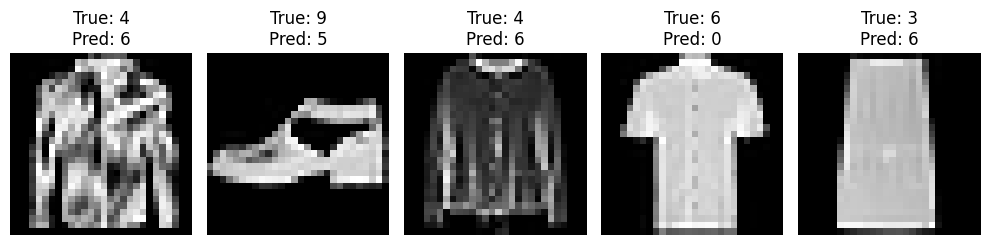

In [8]:
# Find and display misclassified images here

import matplotlib.pyplot as plt

# Get predictions for the test set
y_pred = improved_model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Find misclassified images
misclassified_indices = np.where(y_pred_classes != y_true_classes)[0]

print(f"Found {len(misclassified_indices)} misclassified images.")

# Display 3 to 5 misclassified images
num_to_display = min(5, len(misclassified_indices))

plt.figure(figsize=(10, 10))
for i in range(num_to_display):
    idx = misclassified_indices[i]
    plt.subplot(1, num_to_display, i + 1)
    plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')
    plt.title(f"True: {y_true_classes[idx]}\nPred: {y_pred_classes[idx]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

*Your observations about the misclassified images:*

The misclassifications primarily occur between visually similar apparel categories, such as confusing coats with shirts or pullovers. These errors happen because the items share nearly the same low-resolution silhouettes. Without fine-grained texture details or distinct color boundaries, the model struggles to differentiate between items with structural overlap.


---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.